In [1]:
import torch
import torchvision
from src.vmmdref.VMMDDiagonal1Channel import VMMDDiagonal1Channel
from torch import nn
from torchvision.transforms import transforms

from src.models.autoencoder.resnet.ResNet18AutoEncoder import ResNet18AutoEncoder
from src.models.autoencoder.resnet.ResNet50AutoEncoder import ResNet50AutoEncoder
from src.models.generator.convolution.GeneratorConvLinearMappingBigSigmV2 import GeneratorConvLinearMappingBigSigmV2
from src.vmmdref.VMMDConvLinearMappingRef import VMMDConvLinearMappingRef

In [2]:
import numpy as np
from sklearn.model_selection import ParameterSampler

def generate_hyperparams(n_iter=10, random_state=777):
    """
    Generates a list of dictionaries, each containing a random combination
    of hyperparameters for model tuning.

    :param n_iter:        How many random hyperparameter sets to generate.
    :param random_state:  Seed for reproducibility.
    :return:              A list of dictionaries with hyperparameter configurations.
    """

    # Define your hyperparameter search space
    param_distributions = {
        'batch_size':    [128, 256, 500, 1024],
        'epochs':        [100, 200, 300, 400],
        'lr':            np.logspace(-4, -1, 8),     # e.g., [1e-4, 1e-3, 1e-2, 1e-1]
        'momentum':      np.linspace(0.8, 0.99, 5),  # e.g., [0.8, 0.85, 0.9, 0.95, 0.99]
        'seed':          [777, 111, 222, 333],
        'weight_decay':  np.logspace(-4, -1, 4), # e.g., [1e-4, 1e-3, 1e-2, 1e-1]
        'latent_size': [64, 256, 512, 1024]
    }

    # Randomly sample n_iter configurations from the above distributions
    sampler = ParameterSampler(param_distributions, n_iter=n_iter, random_state=random_state)

    # Convert the iterator to a list of dictionaries
    param_list = list(sampler)
    return param_list

In [3]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
 #       transforms.Normalize(mean=[0.4955, 0.4564, 0.4155], std=[0.2568, 0.2523, 0.2580])
     ]
)
dataset = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True,
                                       transform=transform)
cats_dataset = [(img, label) for (img, label) in dataset if label == 3]

Files already downloaded and verified


In [ ]:
from src.models.generator.linear_mapping.GeneratorLinearMappingTanh import GeneratorLinearMappingTanh
from src.vmmdref.VMMDLinearMappingRef import VMMDLinearMappingRef

hyperparameter_list = generate_hyperparams(n_iter=10, random_state=777)
for i in range(len(hyperparameter_list)):
    vmmd =VMMDLinearMappingRef(
        filename=f"linear_mapping_hypparam_0_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=hyperparameter_list[i]['epochs'],
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorLinearMappingTanh(noise_dim))

Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


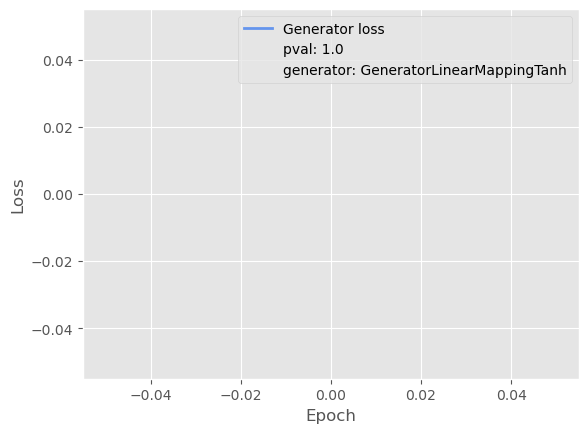

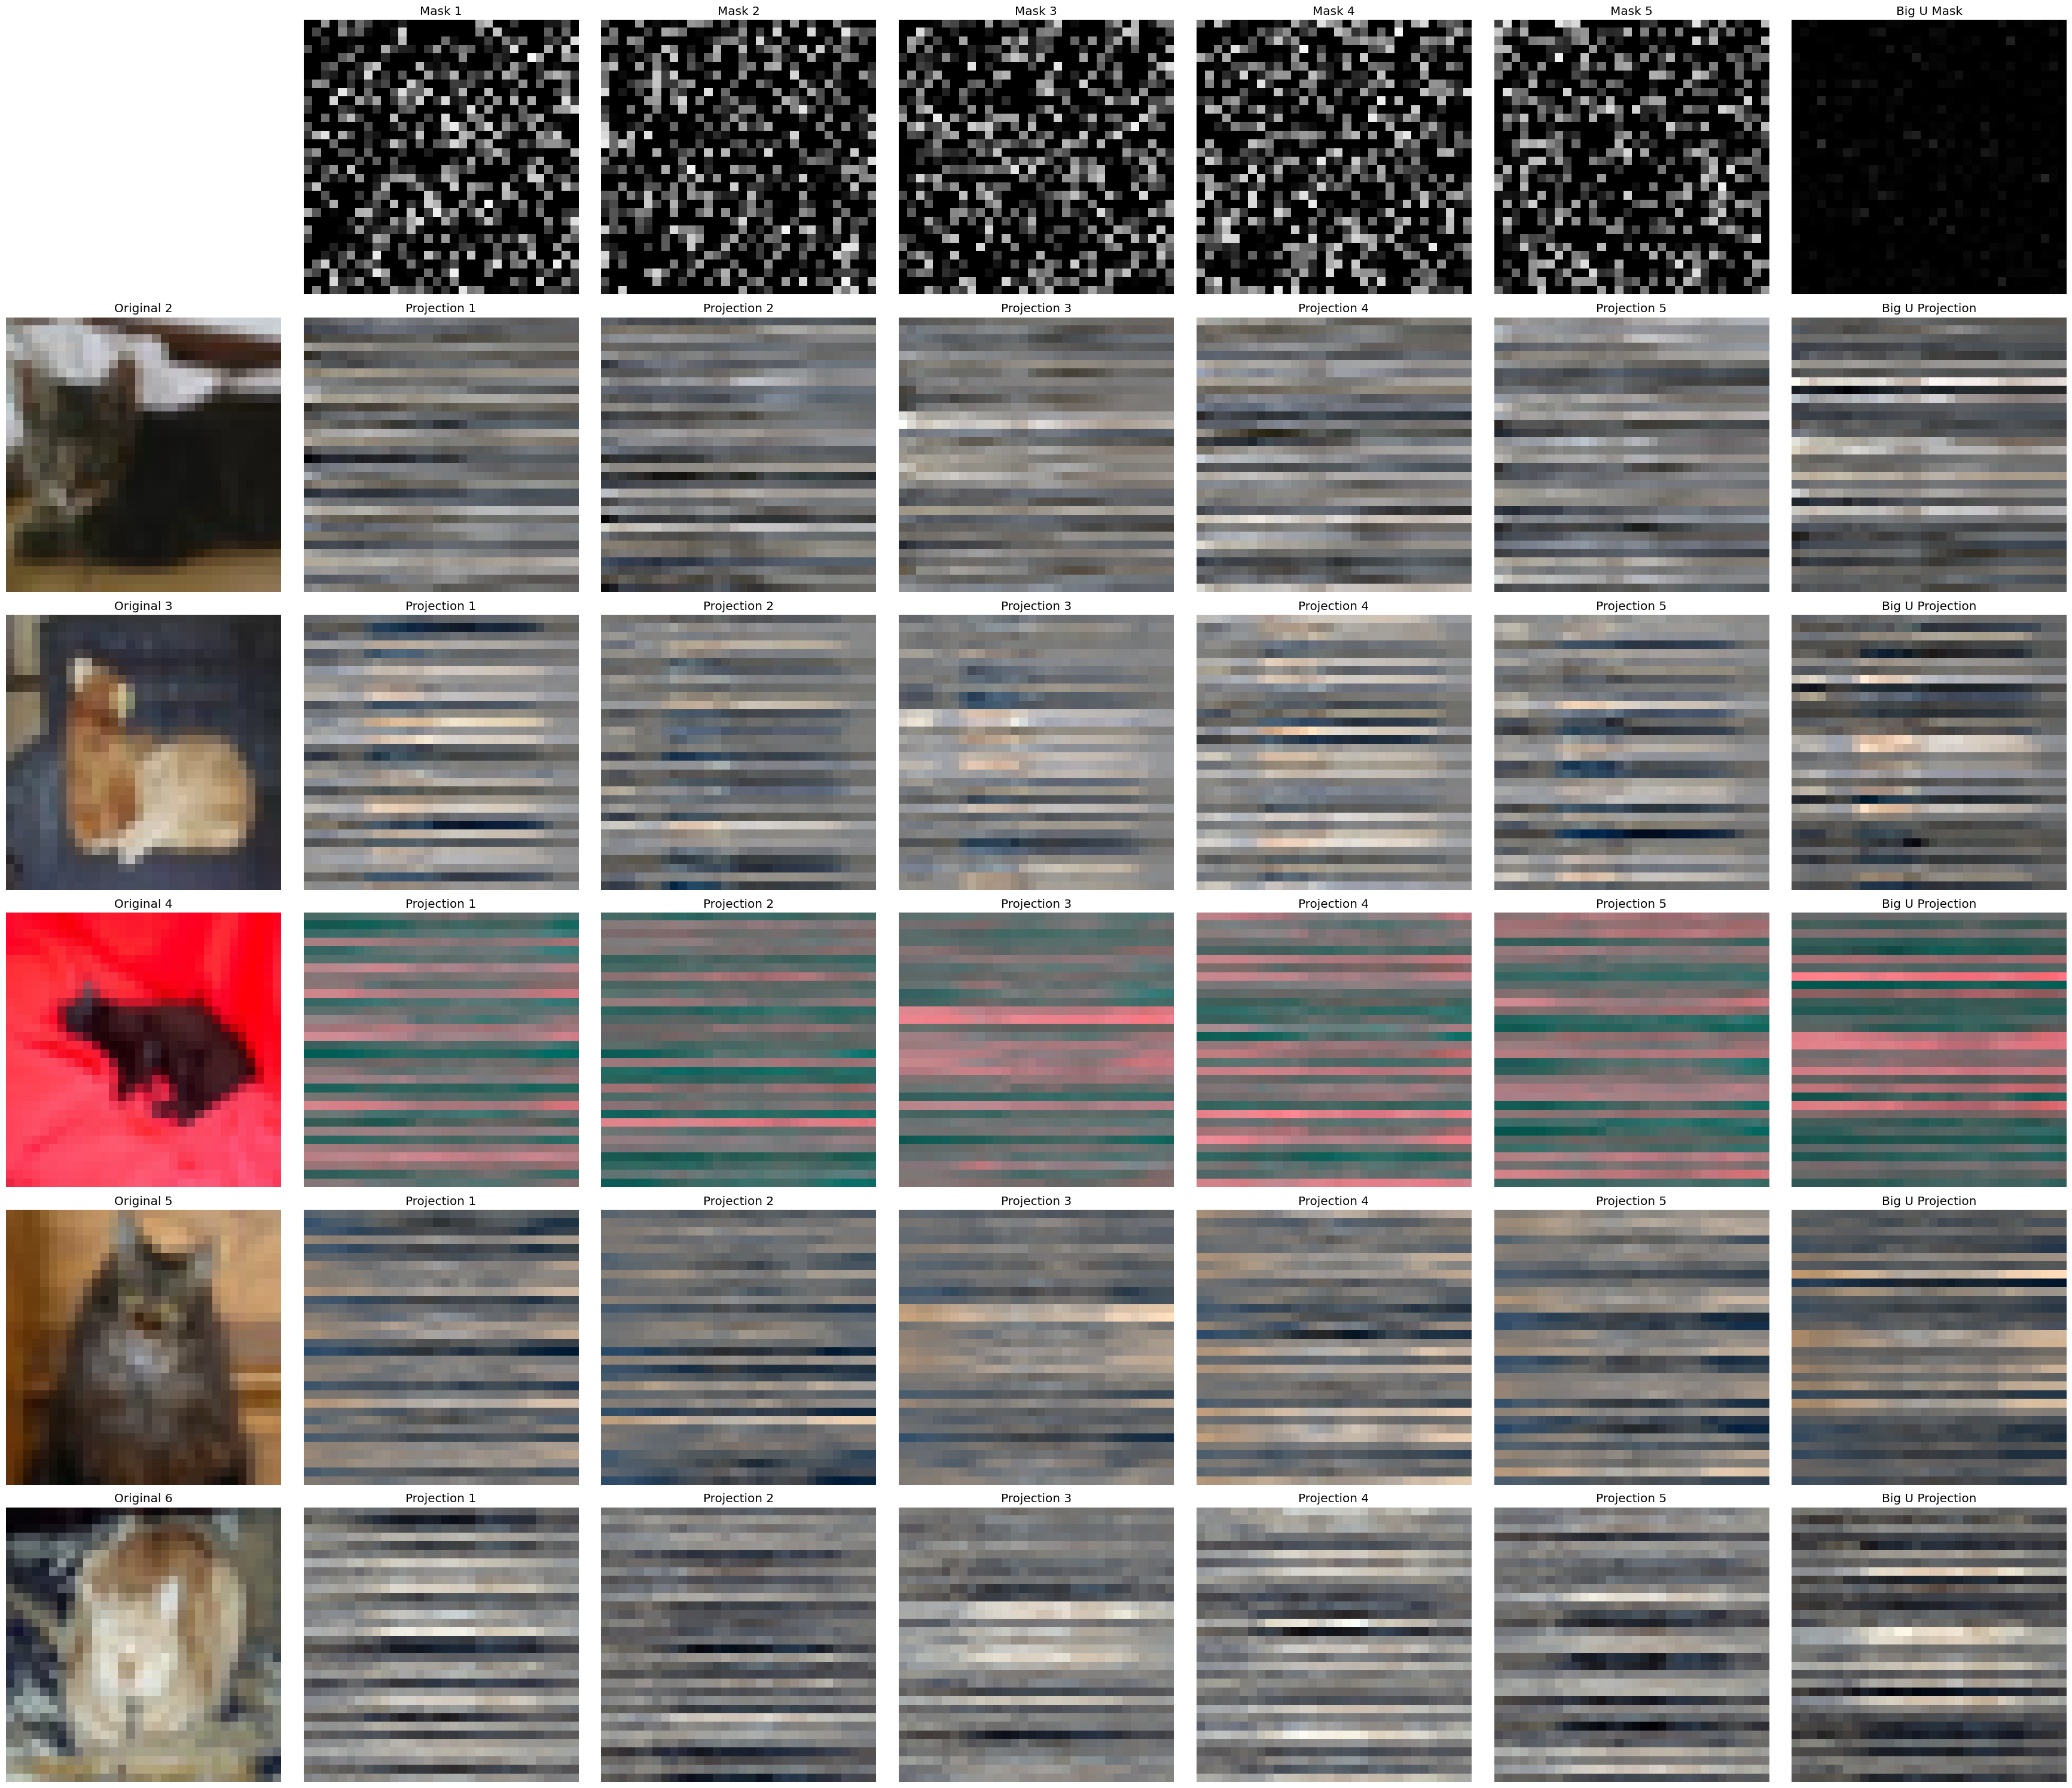

Epoch 0 of 400


Average loss in the epoch: 0.4912823289632797
Epoch 1 of 400


Average loss in the epoch: 0.49757518619298935
Epoch 2 of 400


Average loss in the epoch: 0.49588601291179657
Epoch 3 of 400


Average loss in the epoch: 0.4950382560491562
Epoch 4 of 400


...

Average loss in the epoch: 0.49417849630117416
Epoch 15 of 400


Average loss in the epoch: 0.4922369047999382
Epoch 16 of 400


Average loss in the epoch: 0.49101240187883377
Epoch 17 of 400


Average loss in the epoch: 0.4933885186910629
Epoch 18 of 400


 50%|█████     | 2/4 [00:00<00:00,  5.37it/s]

In [ ]:
from src.models.generator.linear_mapping.GeneratorLinearMappingTanh import GeneratorLinearMappingTanh
from src.vmmdref.VMMDLinearMappingRef import VMMDLinearMappingRef

hyperparameter_list = generate_hyperparams(n_iter=9, random_state=777)
for i in range(1, len(hyperparameter_list)):
    vmmd =VMMDLinearMappingRef(
        filename=f"linear_mapping_hypparam_1_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=hyperparameter_list[i]['epochs'],
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet50AutoEncoder(), GeneratorLinearMappingTanh(noise_dim))

In [ ]:
from src.models.generator.diagonal_matrix.three_channels.GeneratorThreeChannel import GeneratorThreeChannel
from src.vmmdref.VMMDDiagonal3Channel import VMMDDiagonal3Channel

hyperparameter_list = generate_hyperparams(n_iter=10, random_state=777)
for i in range(len(hyperparameter_list)):
    vmmd =VMMDDiagonal3Channel(
        filename=f"three_channel_hypparam_0_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=hyperparameter_list[i]['epochs'],
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorThreeChannel(noise_dim))

In [ ]:
from src.models.generator.diagonal_matrix.one_channel.GeneratorOneChannelResidual import GeneratorOneChannelResidual

hyperparameter_list = generate_hyperparams(n_iter=9, random_state=777)
for i in range(1, len(hyperparameter_list)):
    vmmd =VMMDDiagonal1Channel(
        filename=f"one_channel_hypparam_0_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=hyperparameter_list[i]['epochs'],
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorOneChannelResidual(noise_dim))

In [5]:
hyperparameter_list = generate_hyperparams(n_iter=10, random_state=777)

for i in range(len(hyperparameter_list)):
    vmmd = VMMDConvLinearMappingRef(
        filename=f"conv_hypparam_tuning_3_test_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=hyperparameter_list[i]['epochs'],
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = torch.tensor([hyperparameter_list[i]['latent_size'], 1, 1])
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorConvLinearMappingBigSigmV2(noise_dim))

OutOfMemoryError: CUDA out of memory. Tried to allocate 250.00 MiB. GPU 0 has a total capacity of 23.65 GiB of which 249.12 MiB is free. Process 1509249 has 630.00 MiB memory in use. Process 1511175 has 6.24 GiB memory in use. Process 1534253 has 6.37 GiB memory in use. Including non-PyTorch memory, this process has 10.16 GiB memory in use. Of the allocated memory 9.50 GiB is allocated by PyTorch, and 186.11 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)